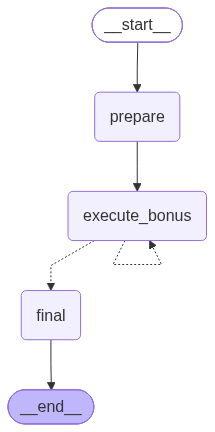

【初始状态】 BONUS_DB: {'E1001': 0}
[准备阶段] 生成 idempotency_key: a3315a73-e1da-4705-b6d4-0882248b2124

[执行阶段] 第 1 次尝试调用工具...
  -> [底层执行] 第一次收到该 Key，执行加钱逻辑: BONUS_DB['E1001'] += 5000
  -> [网络模拟] 💥 致命情况！底层已成功，但假装网络超时没收到响应！抛出 TimeoutError...

[执行阶段] 第 2 次尝试调用工具...
  -> [底层拦截] 发现重复执行！Key已存在，直接返回上一次的成功结果。
  -> [网络模拟] ✅ 这次网络通畅，成功拿到响应！


In [1]:
import os
import re
from typing import Literal
from typing_extensions import TypedDict, Annotated
from IPython.display import Image, display

from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, END, StateGraph
import uuid

import uuid
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph

# ==========================================
# 1. 模拟底层存储 (幂等表 & 业务库)
# ==========================================
IDEMPOTENCY_STORE = {}
BONUS_DB = {
    "E1001": 0
}

# ==========================================
# 2. 定义状态
# ==========================================
class AgentState(TypedDict):
    employee_id: str
    amount: int
    idempotency_key: str
    retry_count: int
    status: str
    error: str
    result: dict

# ==========================================
# 3. 核心工具与节点
# ==========================================
def prepare_operation_node(state: AgentState):
    """节点 1：生成幂等键，准备操作"""
    # 如果已经有 key 了（比如外部传入的），就不用再生成，这里为了演示每次新生成
    operation_id = state.get("idempotency_key") or str(uuid.uuid4())
    print(f"[准备阶段] 生成 idempotency_key: {operation_id}")
    return {
        "idempotency_key": operation_id,
        "retry_count": 0,
        "status": "prepared",
    }

def give_bonus(employee_id: str, amount: int, idempotency_key: str):
    """核心工具：发奖金 (包含幂等检查)"""
    # 1. 查幂等表
    existing = IDEMPOTENCY_STORE.get(idempotency_key)
    if existing:
        print(f"  -> [底层拦截] 发现重复执行！Key已存在，直接返回上一次的成功结果。")
        return existing["result"]

    # 2. 模拟业务处理：加钱
    print(f"  -> [底层执行] 第一次收到该 Key，执行加钱逻辑: BONUS_DB['{employee_id}'] += {amount}")
    BONUS_DB[employee_id] += amount

    result = {
        "employee_id": employee_id,
        "amount": amount,
        "total_bonus": BONUS_DB[employee_id],
    }

    # 3. 记录到幂等表
    IDEMPOTENCY_STORE[idempotency_key] = {
        "status": "completed",
        "result": result,
    }
    return result

def execute_bonus_node(state: AgentState):
    """节点 2：执行操作，故意在第一次引发超时"""
    print(f"\n[执行阶段] 第 {state['retry_count'] + 1} 次尝试调用工具...")
    try:
        # 调用底层工具
        result = give_bonus(
            employee_id=state["employee_id"],
            amount=state["amount"],
            idempotency_key=state["idempotency_key"],
        )

        # 故意制造惨案：底层已经加完钱了，但在把结果传回去的路上，Timeout 丢包了！
        if state["retry_count"] == 0:
            print("  -> [网络模拟] 💥 致命情况！底层已成功，但假装网络超时没收到响应！抛出 TimeoutError...")
            raise TimeoutError("Response timeout from Give Bonus Service")

        print("  -> [网络模拟] ✅ 这次网络通畅，成功拿到响应！")
        return {
            "status": "success",
            "result": result,
        }

    except TimeoutError as e:
        return {
            "status": "retryable_error",
            "error": str(e),
            "retry_count": state["retry_count"] + 1, # 重试次数 +1
        }

# ==========================================
# 4. 图路由与构建
# ==========================================
def route_after_execute(state: AgentState):
    if state["status"] == "retryable_error":
        return "execute_bonus" # 遇到可重试错误，再来一次
    return "final"

builder = StateGraph(AgentState)
builder.add_node("prepare", prepare_operation_node)
builder.add_node("execute_bonus", execute_bonus_node)
builder.add_node("final", lambda state: state) # 终点节点什么都不做

builder.add_edge(START, "prepare")
builder.add_edge("prepare", "execute_bonus")
builder.add_conditional_edges("execute_bonus", route_after_execute, {
    "execute_bonus": "execute_bonus",
    "final": "final"
})
builder.add_edge("final", END)
graph = builder.compile()

# 显示流程图
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

# ==========================================
# 5. 见证奇迹的时刻
# ==========================================
print("【初始状态】 BONUS_DB:", BONUS_DB)
print("="*60)

final_state = graph.invoke({
    "employee_id": "E1001",
    "amount": 5000
})


